<a href="https://colab.research.google.com/github/vicha1234/TelcoChurnPrediction/blob/main/2425610.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization


**Load the data set**

In [3]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
telco=df['Churn']
telco

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [ ]:
print(telco.isnull().sum())

0


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing in TotalCharges BEFORE fill:", df['TotalCharges'].isnull().sum())


Missing in TotalCharges BEFORE fill: 11


In [ ]:
df.fillna({'TotalCharges':0}, inplace=True)

print(df['TotalCharges'].isnull().sum())

0


**EDA Visualization**

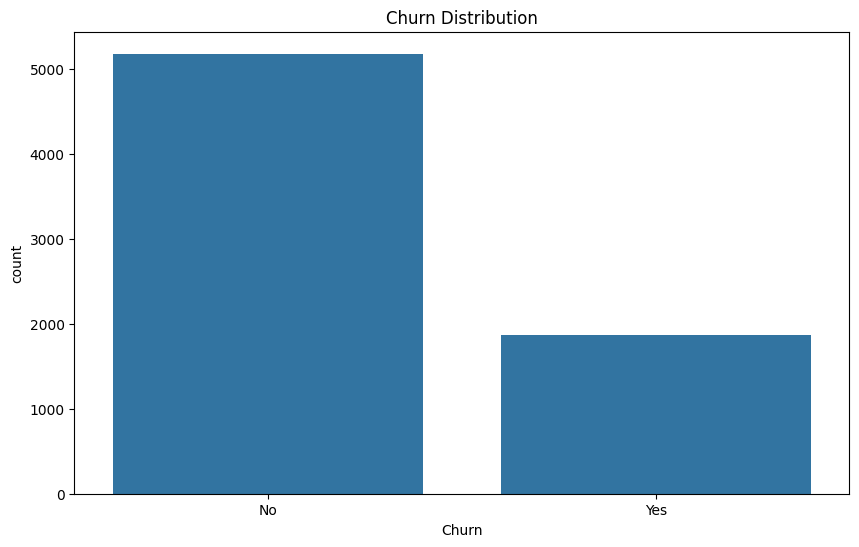

,proportion
Churn,
No,0.73463
Yes,0.26537


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Churn',data=df)
plt.title('Churn Distribution')
plt.show()

df['Churn'].value_counts(normalize=True)

The dataset is imbalanced.Arount 26% customer churn and around 74% customer stay.(The dataset is imbalanced with 26% churn and 74% non-churn.)

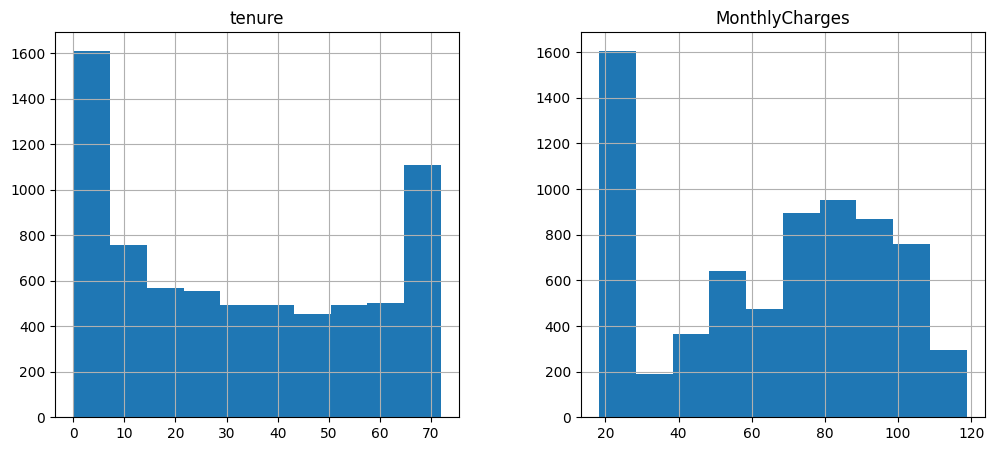

In [ ]:
df[['tenure','MonthlyCharges']].hist(figsize=(12,5))
plt.show()

Tenure distribution shows many customers are relatively new,which may relate to high churn risk.MonthlyCharges has higher values concentrated for churned customers.

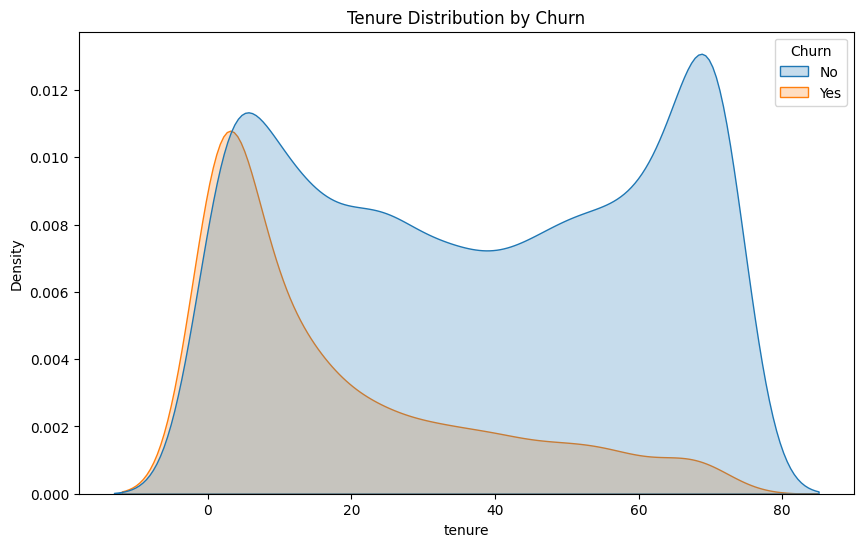

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True)
plt.title("Tenure Distribution by Churn")
plt.show()

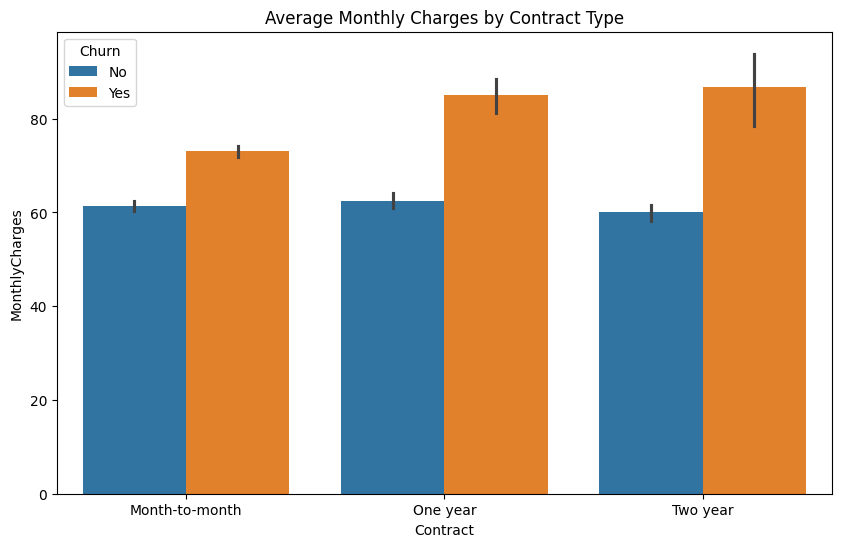

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Average Monthly Charges by Contract Type")
plt.show()

Month to month customers churn the most.One year and two year contract customers rarely churn.Contract length is a strong predictor of churn

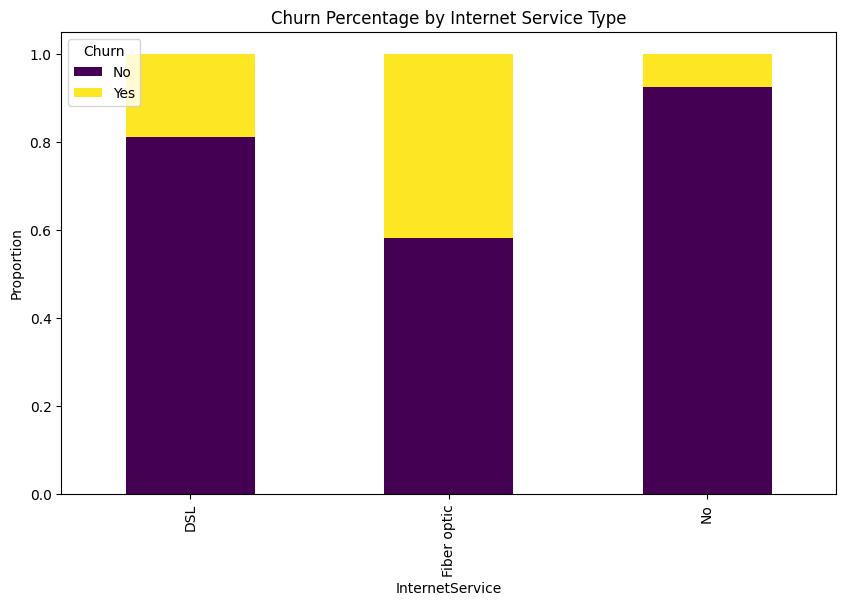

In [ ]:
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct.plot(kind='bar', figsize=(10,6), stacked=True, colormap='viridis')
plt.title("Churn Percentage by Internet Service Type")
plt.ylabel("Proportion")
plt.show()

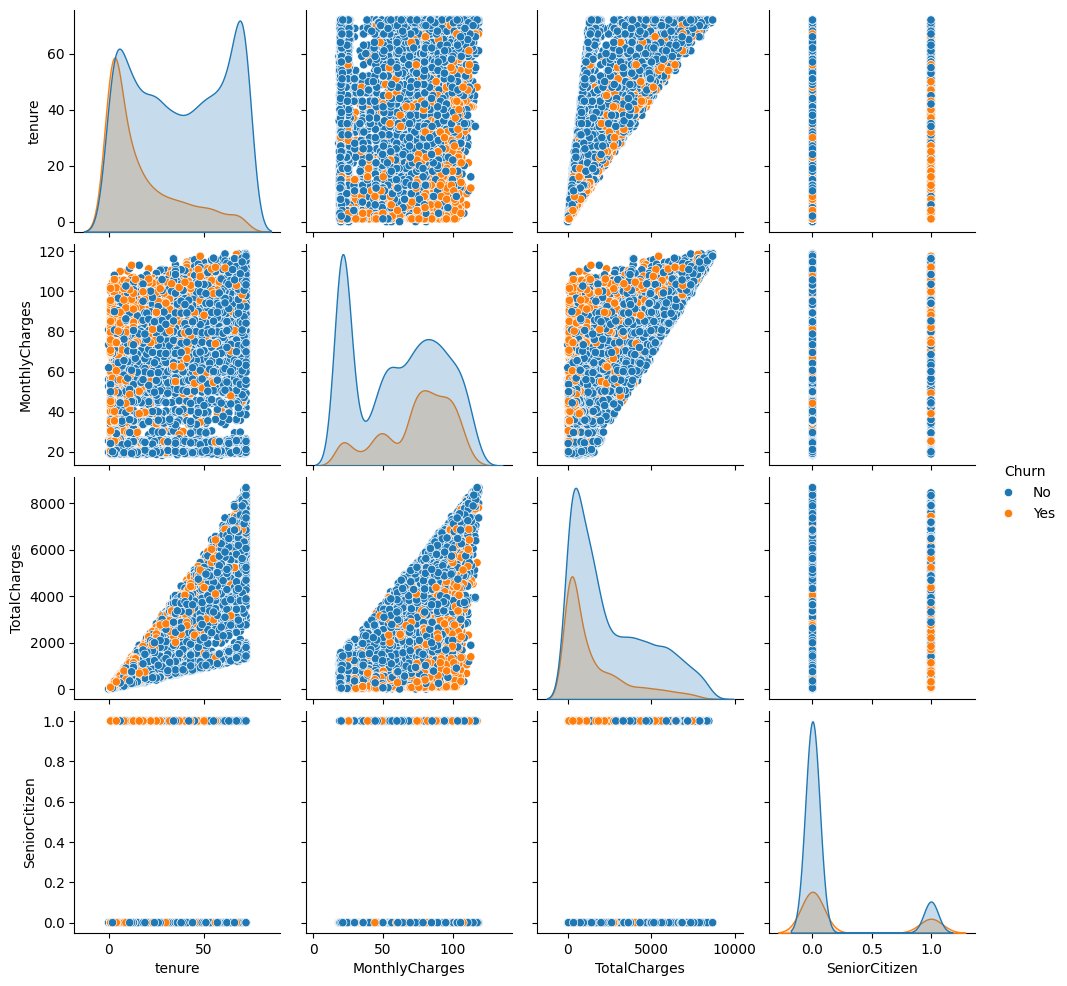

In [ ]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn','SeniorCitizen']], hue='Churn')
plt.show()

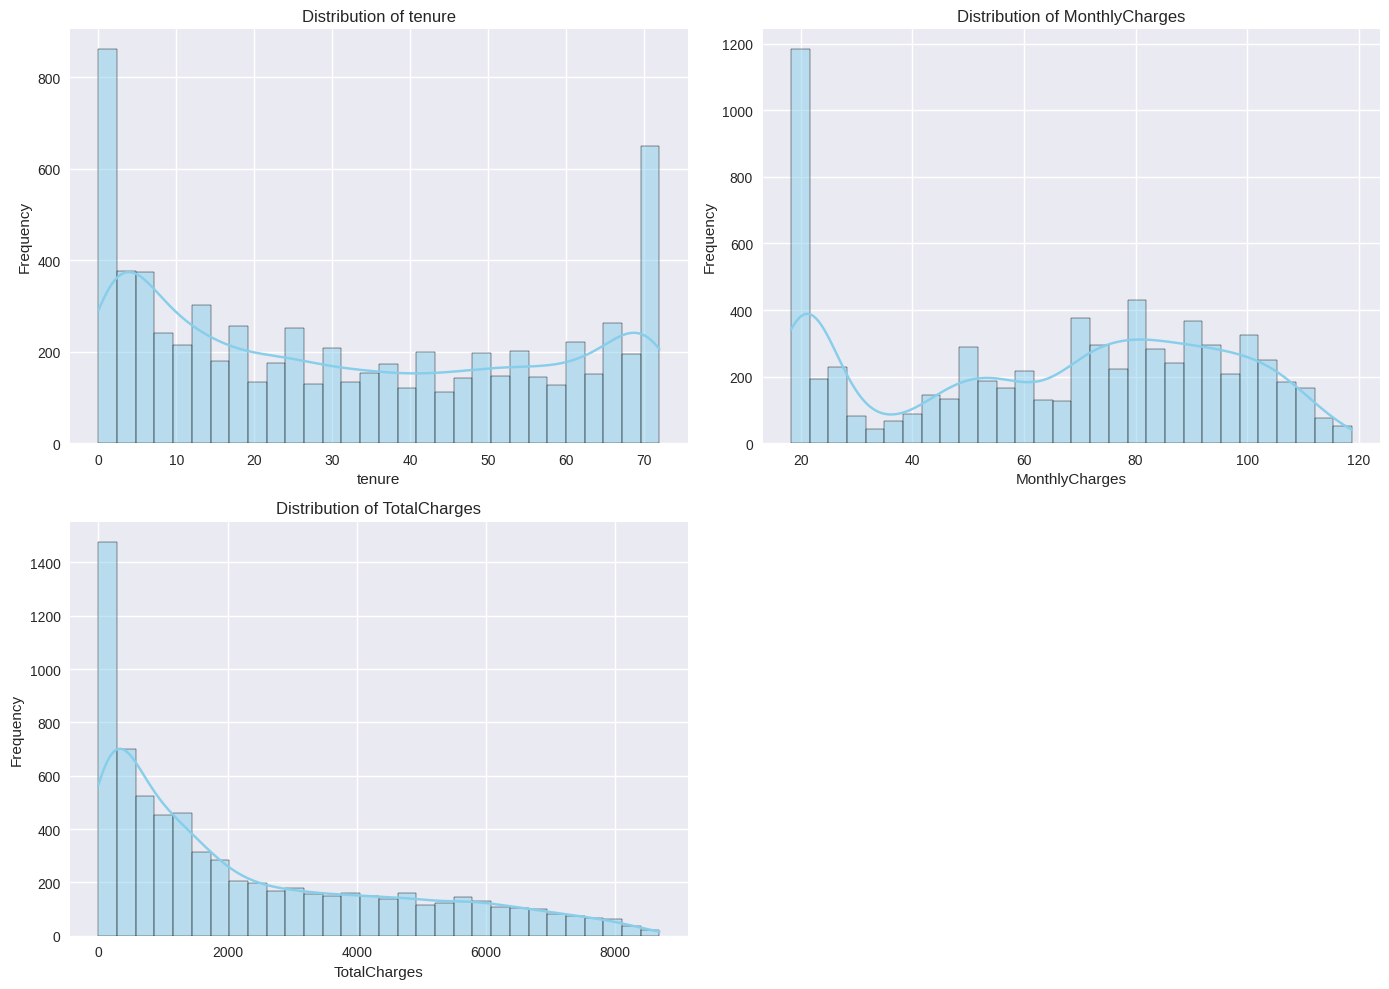

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(14,10))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import zscore

# List of numerical columns
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']


# Function to count IQR outliers
def count_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

# Detect outliers for each numerical column
print("IQR Outliers per Numerical Feature:")
for col in numeric_features:
    n_outliers, lower_bound, upper_bound = count_iqr_outliers(df[col].dropna())
    print(f"{col}: {n_outliers} outliers (outside [{lower_bound:.2f}, {upper_bound:.2f}])")


IQR Outliers per Numerical Feature:
tenure: 0 outliers (outside [-60.00, 124.00])
MonthlyCharges: 0 outliers (outside [-46.02, 171.38])
TotalCharges: 0 outliers (outside [-4683.52, 8868.67])


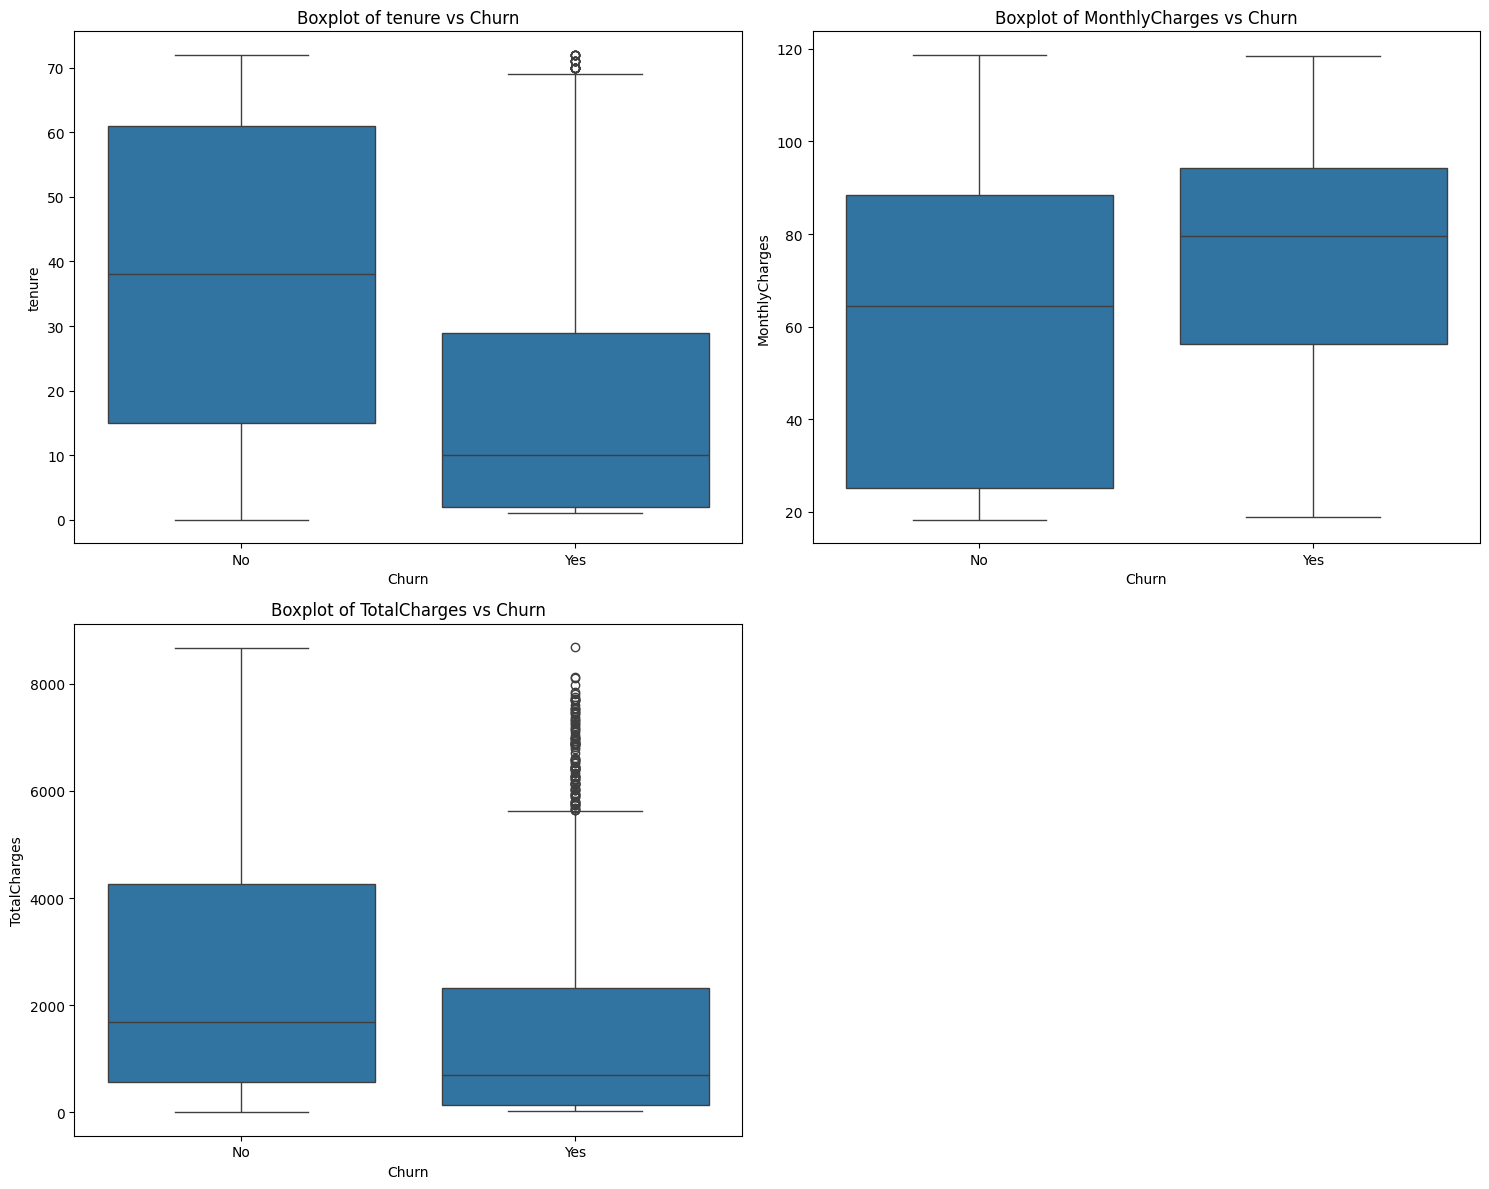

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Plot boxplots for each numerical feature
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'Boxplot of {col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


In [11]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

/tmp/ipython-input-372009398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


/tmp/ipython-input-3220105842.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', legend=False)
/tmp/ipython-input-3220105842.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', legend=False)
/tmp/ipython-input-3220105842.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', legend=False)
/tmp/ipython-input-3220105842.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

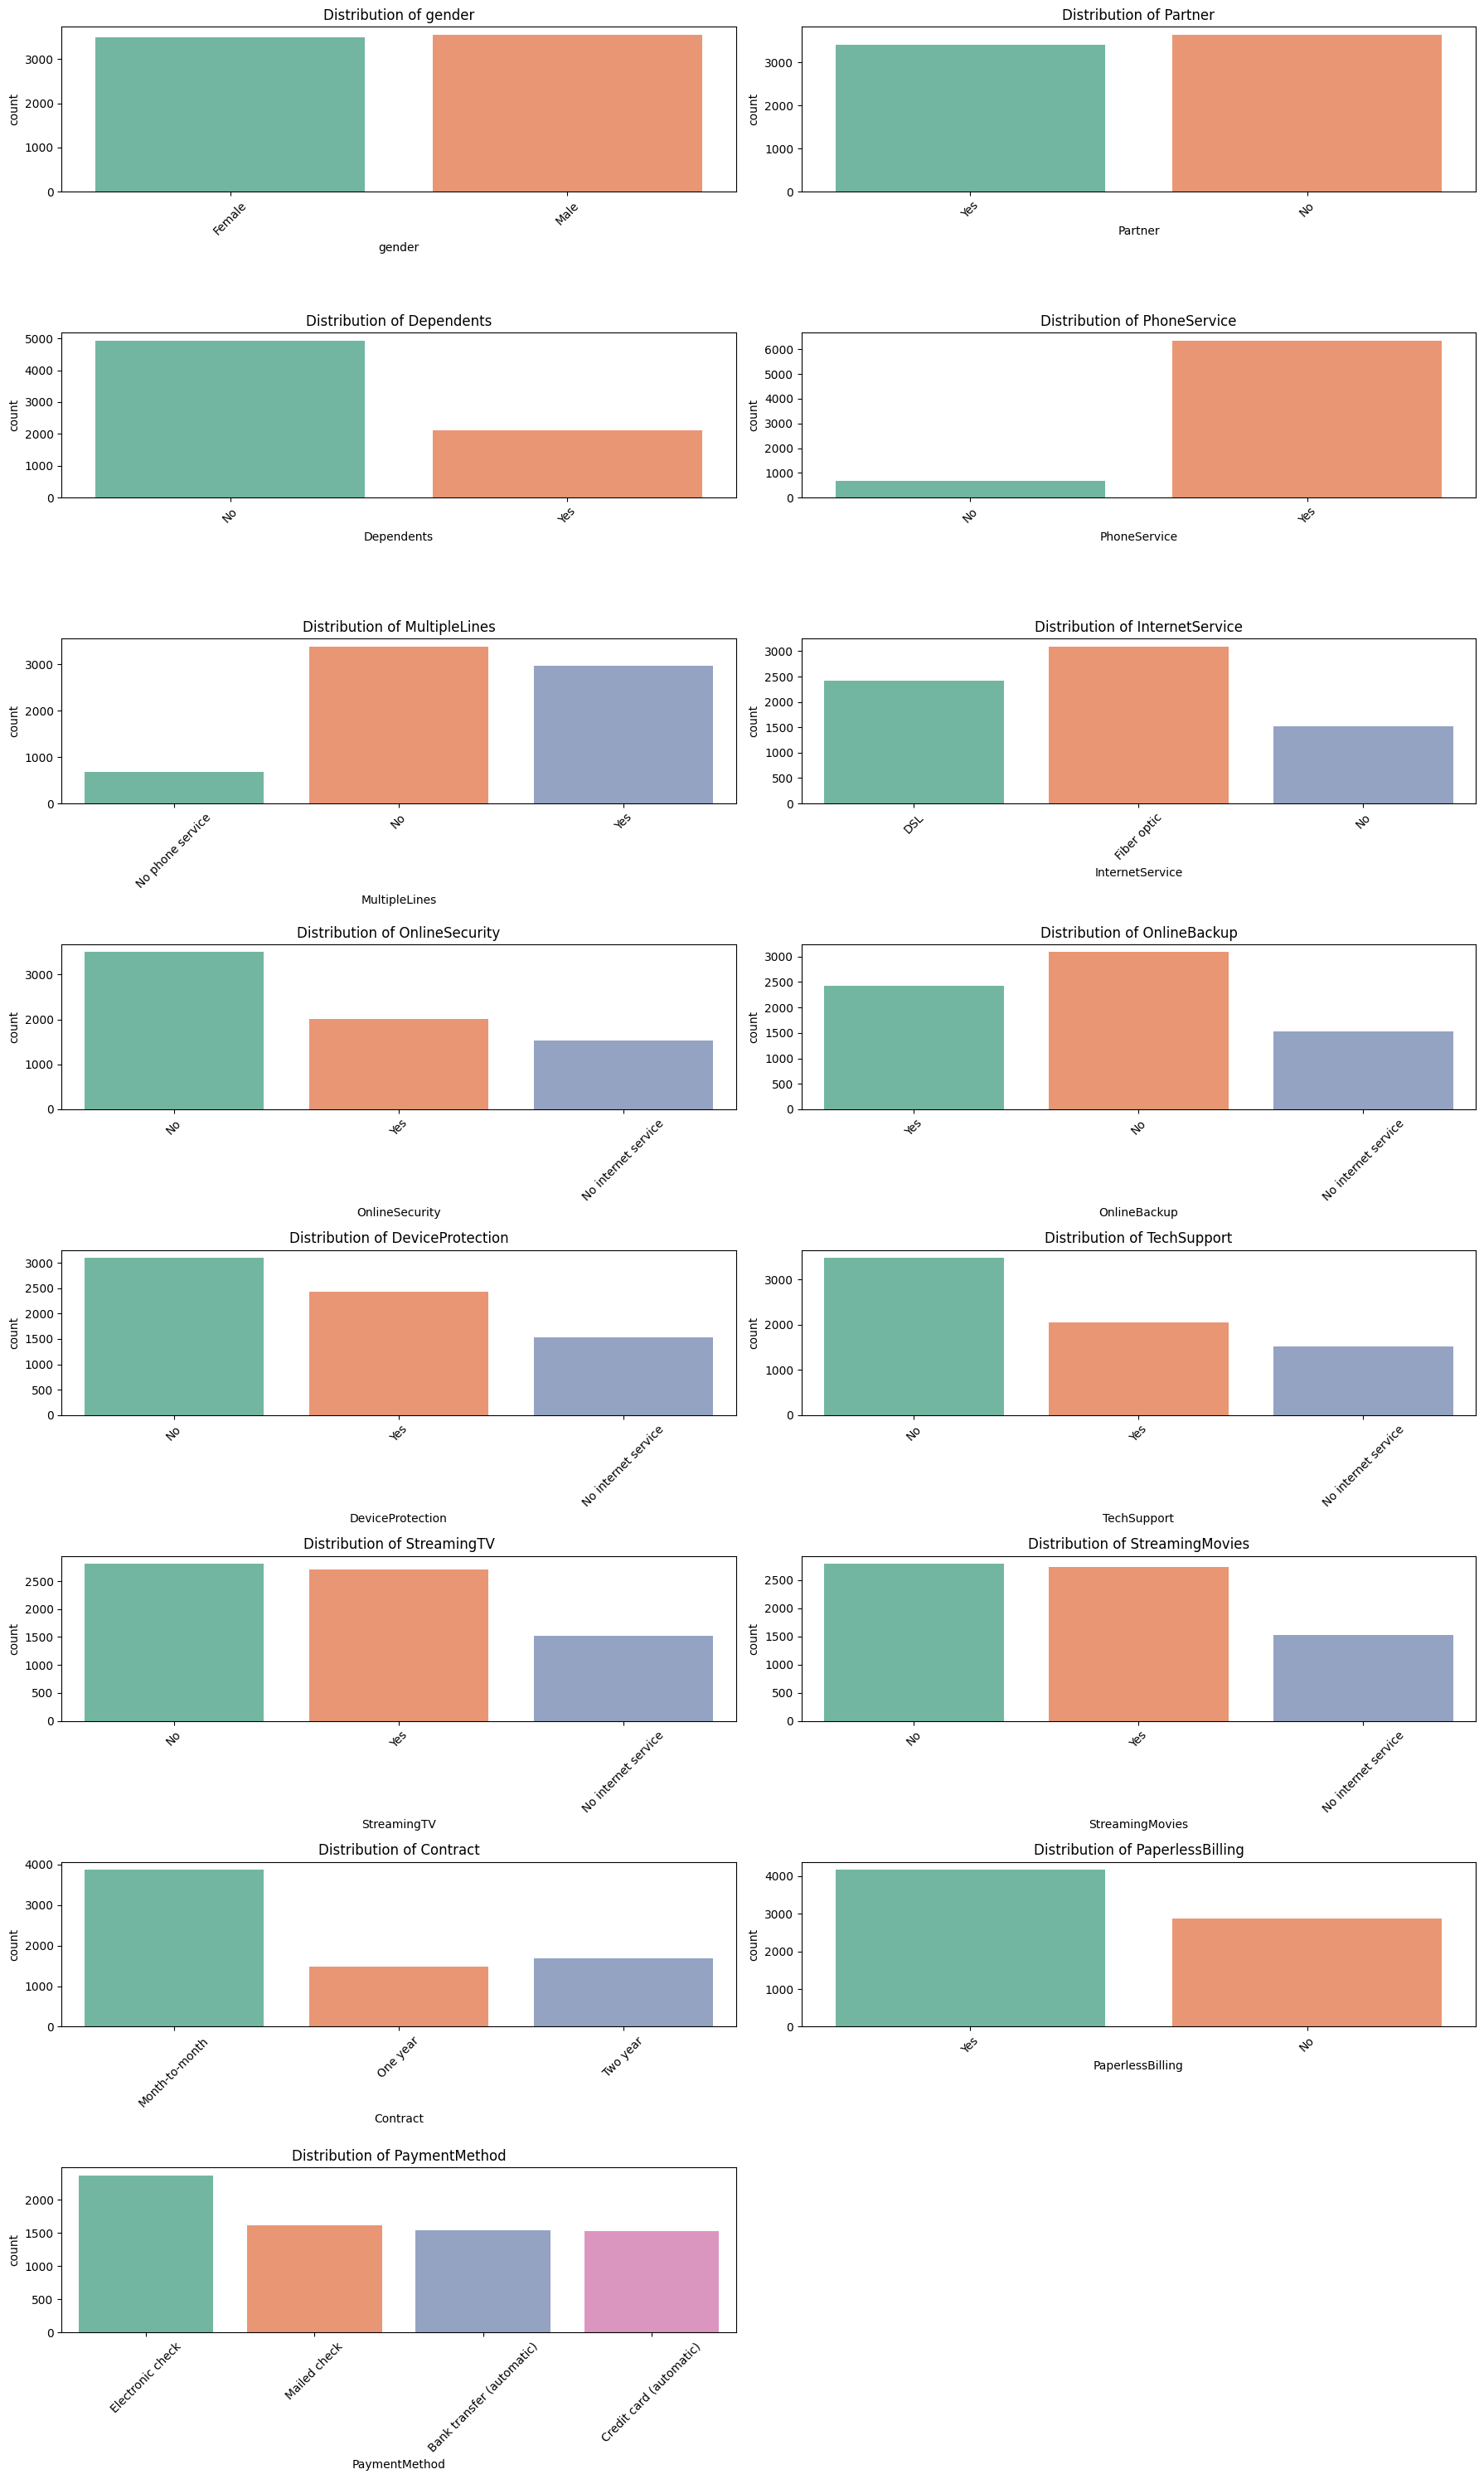

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select categorical columns
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Plot barplots for all categorical features
plt.figure(figsize=(18, 30))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(len(categorical_features)//2 + len(categorical_features)%2, 2, i)
    #sns.countplot(x=col, data=df, palette='Set2', legend=False)
    sns.countplot(x=col, data=df, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


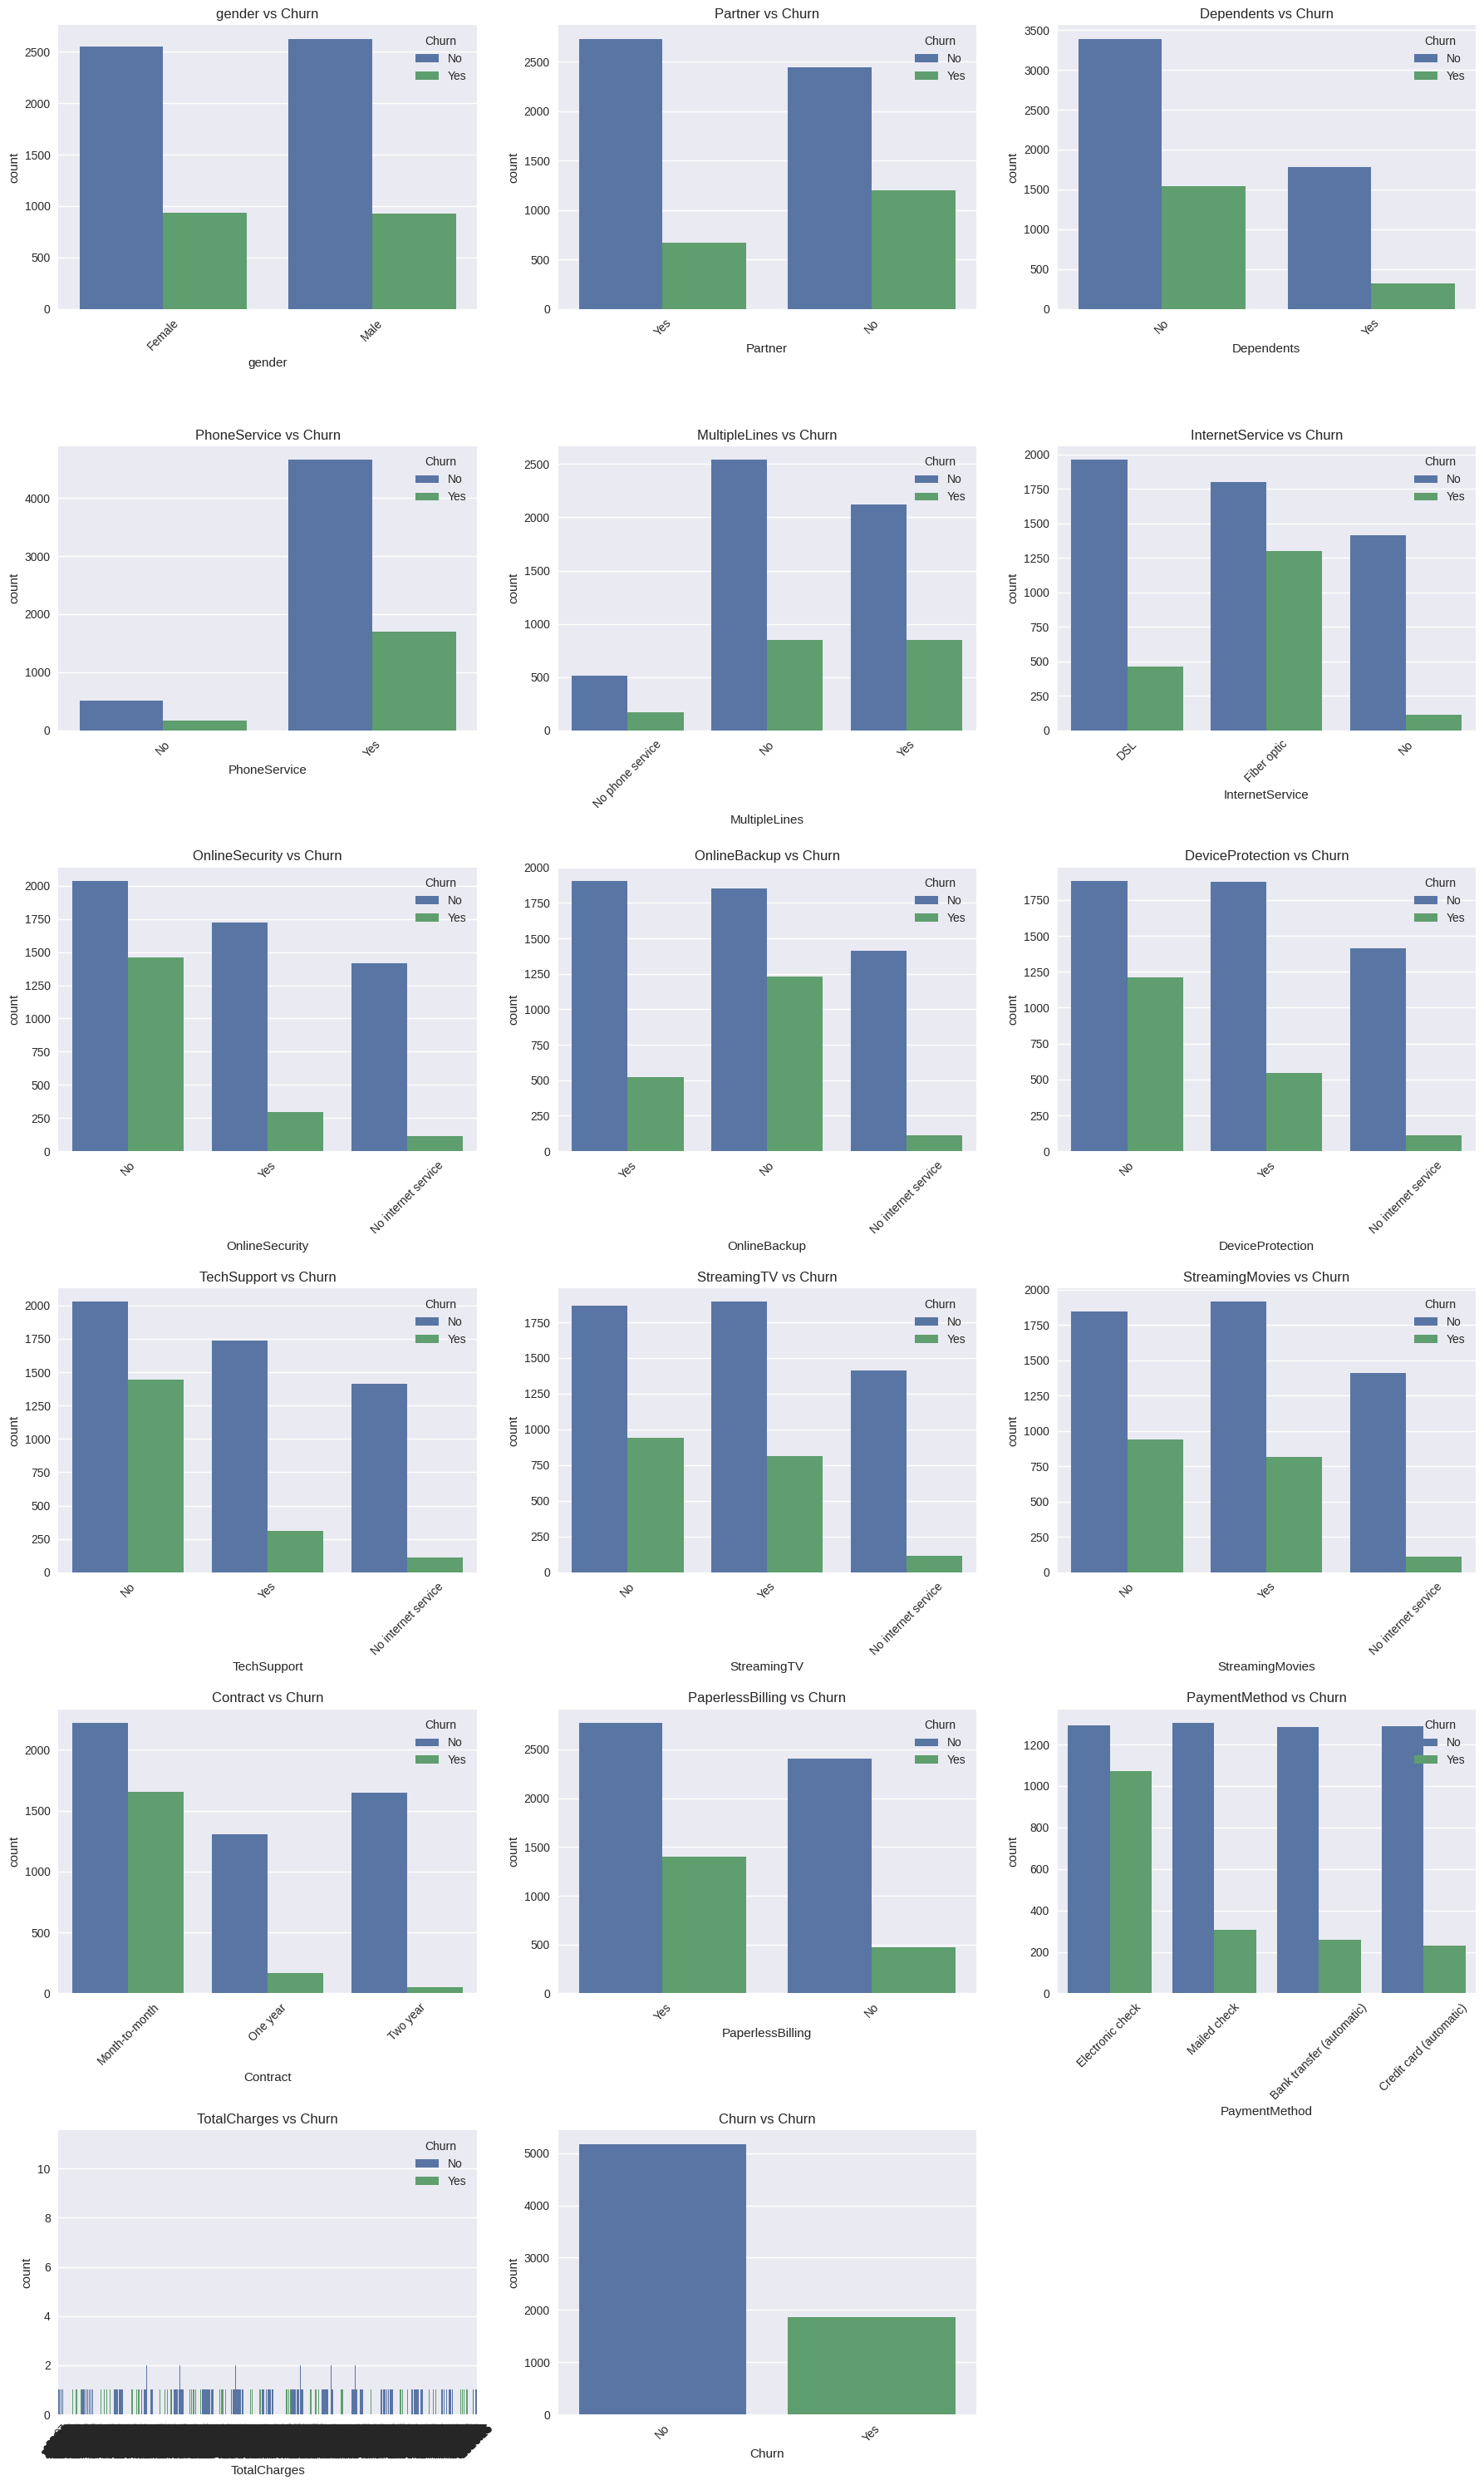

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')   # remove ID column


# Number of plots
n = len(categorical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.style.use("seaborn-v0_8")

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

# Plot each categorical feature
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [5]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing in TotalCharges BEFORE fill:", df['TotalCharges'].isnull().sum())


Missing in TotalCharges BEFORE fill: 11


In [9]:
df.fillna({'TotalCharges':0}, inplace=True)

print(df['TotalCharges'].isnull().sum())

0


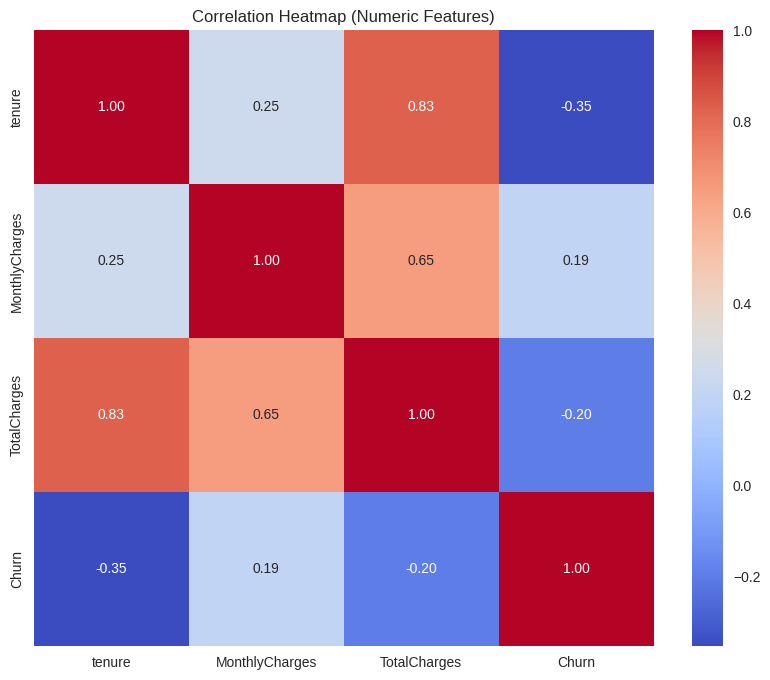

In [12]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges','Churn']

# Compute correlation matrix
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [14]:
#HANDLE “No internet service” CATEGORIES
cols_to_clean = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in cols_to_clean:
    df[col] = df[col].replace({'No internet service': 'No'})
    df[col]=df[col].replace({'No phone service': 'No'})

# **Task 2 - Preprocessing Part**

In [13]:
df = df.drop('customerID', axis=1)

In [15]:
#CONVERT TARGET COLUMN
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [16]:
#Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [17]:
#Encode categorical variables

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes': 1, 'No': 0})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes': 1, 'No': 0})
df['TechSupport']=df['TechSupport'].map({'Yes': 1, 'No': 0})
df['StreamingTV']=df['StreamingTV'].map({'Yes': 1, 'No': 0})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes': 1, 'No': 0})
df['MultipleLines']=df['MultipleLines'].map({'Yes': 1, 'No': 0})


# One-hot encoding example
multi_cat_cols = ['InternetService',
                  'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [18]:
print("\nData info after encoding:")
print(df.info())


Data info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 n

In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
#Split X and y
X=df.drop('Churn',axis=1)
y=df['Churn']

#Train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [22]:
#Feature scaling (numeric features only)
numerical_cols = [col for col in df.columns
                  if df[col].dtype != 'object' and col != 'Churn']


scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [23]:
X_train_scaled=X_train[numerical_cols]
X_test_scaled=X_test[numerical_cols]

In [24]:
print("Before balancing:")
print(y_train.value_counts())

Before balancing:
Churn
0    4139
1    1495
Name: count, dtype: int64


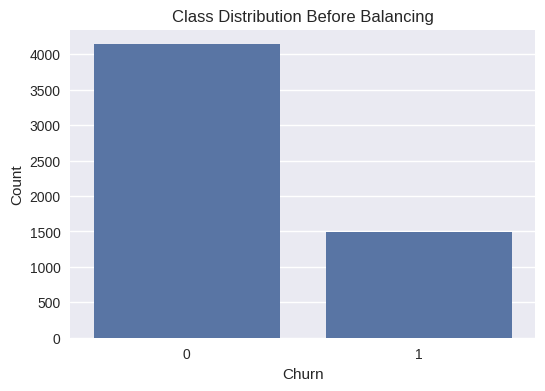

In [25]:
# Visualize before balancing
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [26]:
smote=SMOTE(random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)

y_train_resampled.value_counts()

,count
Churn,
0,4139
1,4139


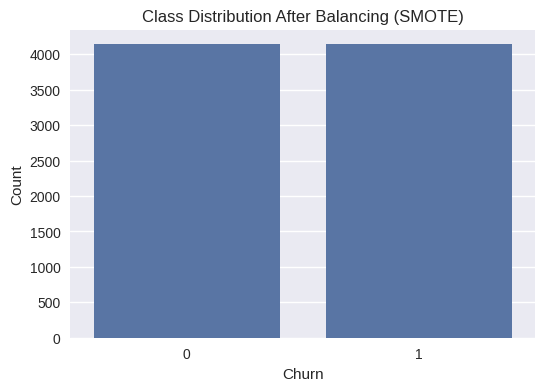

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution After Balancing (SMOTE)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# **Decision Tree**

In [ ]:
#Train decision tree
dt_model=DecisionTreeClassifier(class_weight="balanced",random_state=42)
dt_model.fit(X_train_resampled,y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
#predict on test set
dt_predict=dt_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, dt_predict))
print("Precision:", precision_score(y_test, dt_predict))
print("Recall   :", recall_score(y_test, dt_predict))
print("F1 Score :", f1_score(y_test, dt_predict))

print("\nClassification Report :\n", classification_report(y_test, dt_predict))


Accuracy : 0.7267565649396736
Precision: 0.48735632183908045
Recall   : 0.5668449197860963
F1 Score : 0.5241038318912238

Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.78      0.81      1035
           1       0.49      0.57      0.52       374

    accuracy                           0.73      1409
   macro avg       0.66      0.68      0.67      1409
weighted avg       0.74      0.73      0.73      1409



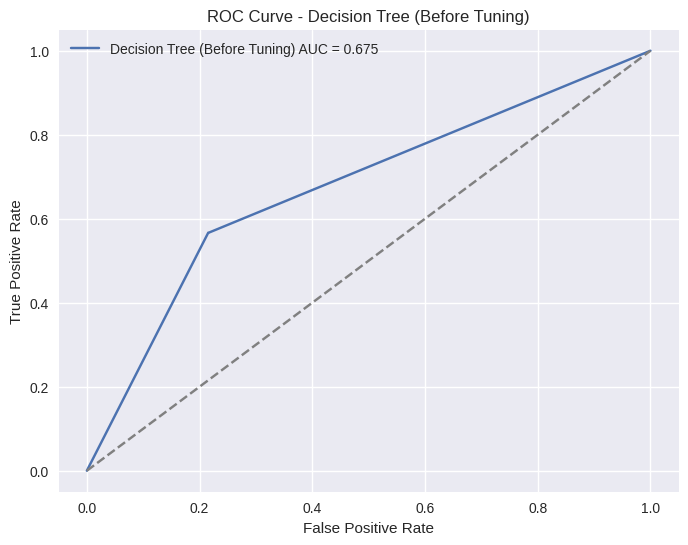

AUC Score (Before Tuning): 0.6754837376320753


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test, model_name="Model"):
    # Predict probability for the positive class (Churn = 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute FPR, TPR
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC score
    auc_score = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{model_name} AUC = {auc_score:.3f}')
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    return auc_score

auc_before_dt = plot_roc_curve(dt_model, X_test, y_test, "Decision Tree (Before Tuning)")
print("AUC Score (Before Tuning):", auc_before_dt)


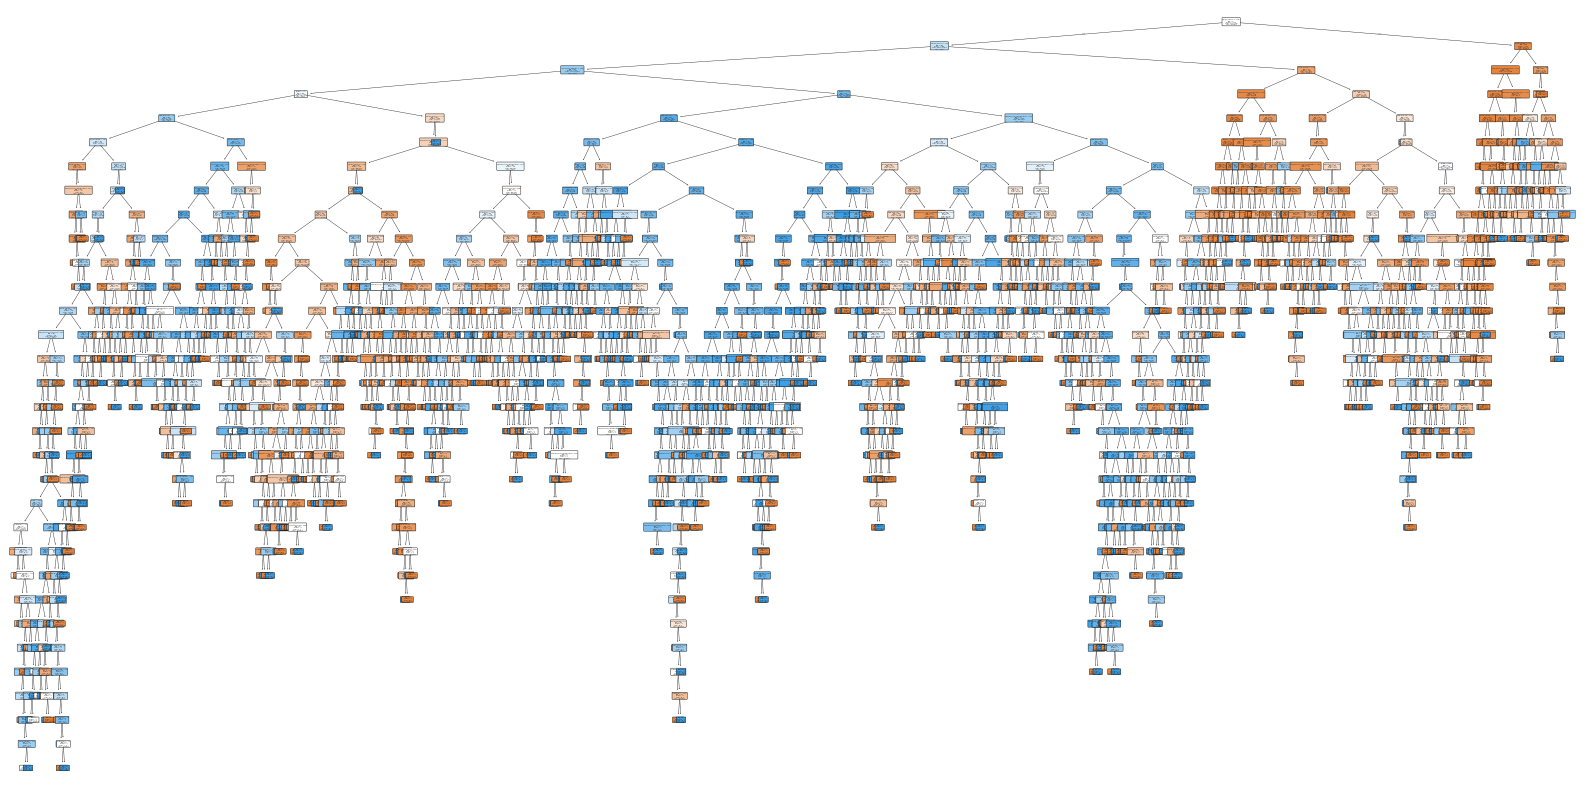

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Churn','Churn'], filled=True, rounded=True)
plt.show()

In [ ]:
#Hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt=DecisionTreeClassifier(random_state=42)

grid_search=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

grid_search.fit(X_train_resampled,y_train_resampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [ ]:
#Best model
print("Best Parameters : ",grid_search.best_params_)
best_dt=grid_search.best_estimator_

Best Parameters :  {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}


In [ ]:
#Evaluate best decision tree
best_predict=best_dt.predict(X_test)

print("Accuracy :",accuracy_score(y_test,best_predict))
print("Precision :",precision_score(y_test,best_predict))
print("Recall :",recall_score(y_test,best_predict))
print("F1 score :",f1_score(y_test,best_predict))

print("\nClassification Report :\n",classification_report(y_test,best_predict))


Accuracy : 0.7416607523066004
Precision : 0.5100806451612904
Recall : 0.6764705882352942
F1 score : 0.5816091954022988

Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.77      0.81      1035
           1       0.51      0.68      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409



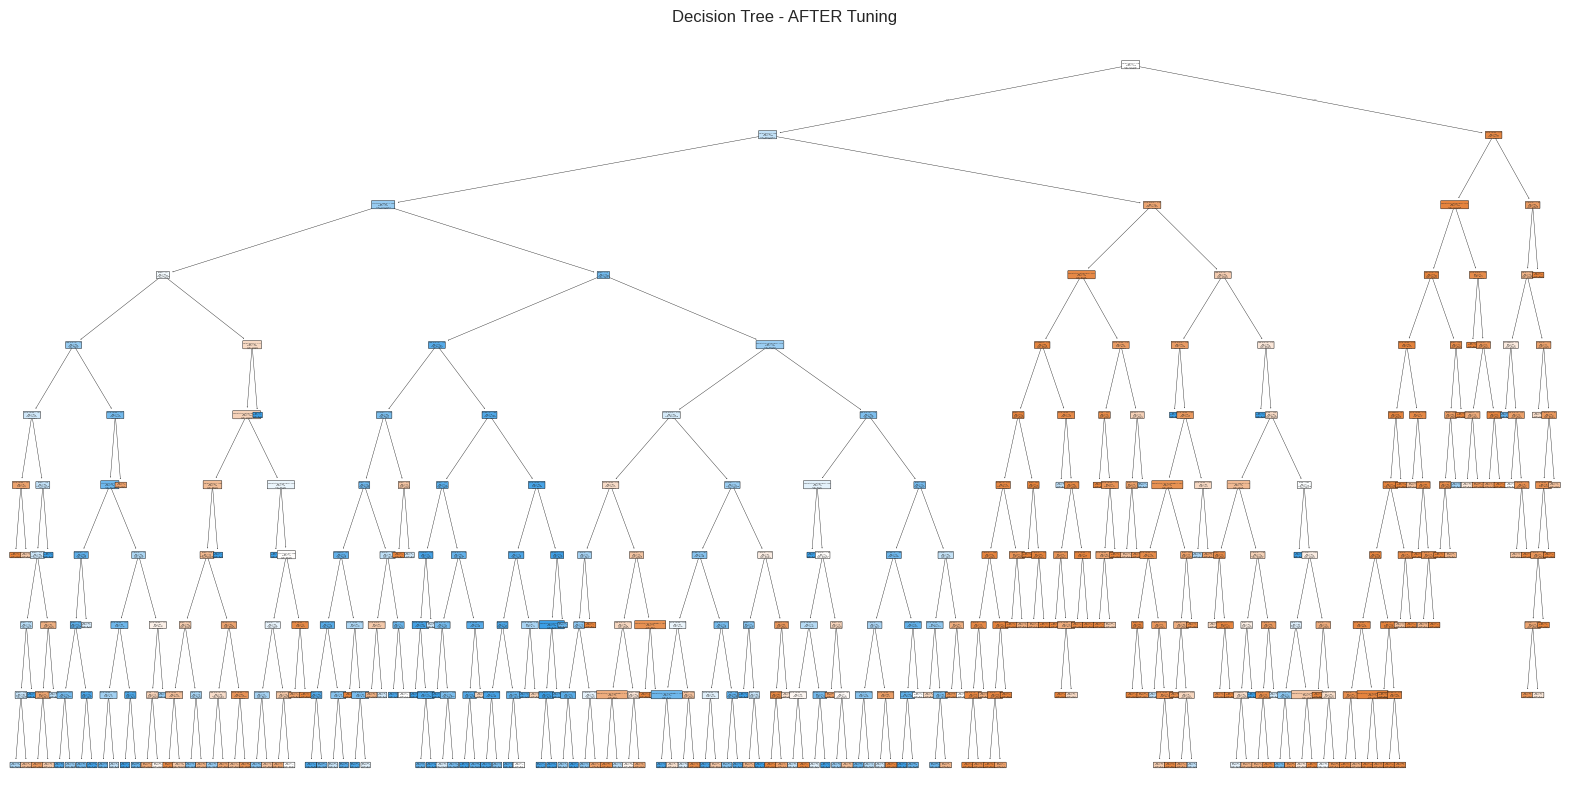

In [ ]:
# AFTER tuning
plt.figure(figsize=(20,10))
plot_tree(best_dt,
          feature_names=X.columns,
          class_names=['No Churn','Churn'],
          filled=True, rounded=True)
plt.title("Decision Tree - AFTER Tuning")
plt.show()

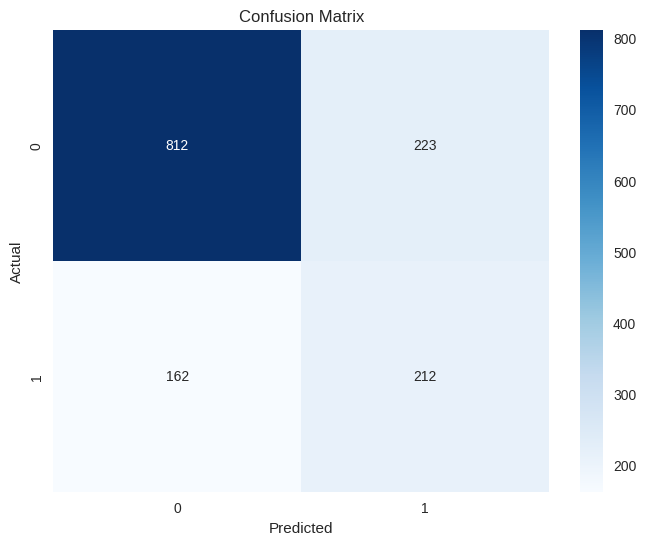

In [ ]:
#Confusion Matrix
cm=confusion_matrix(y_test,dt_predict)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

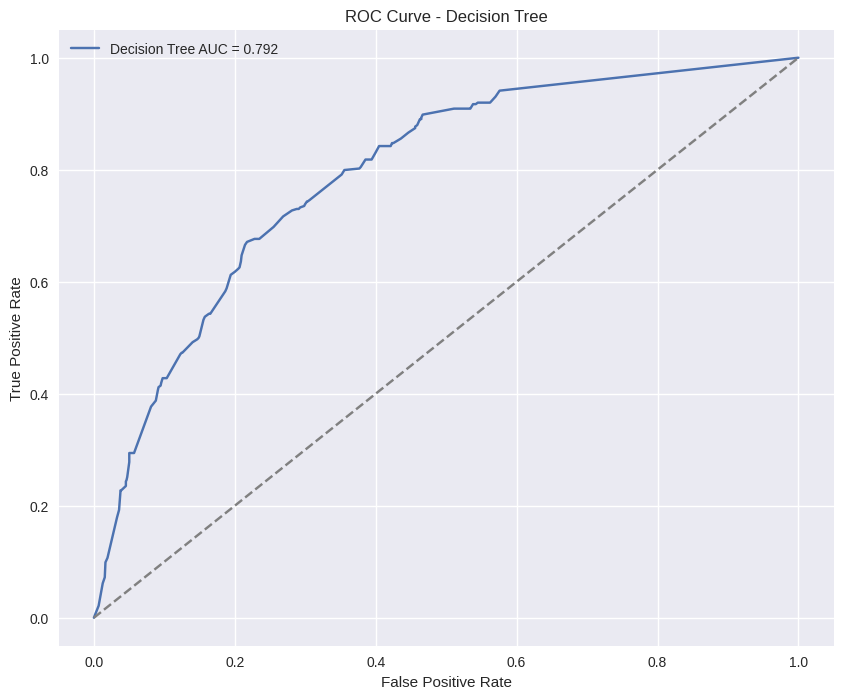

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test, model_name="Model"):
    # Predict probabilities (positive class)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute FPR, TPR
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC
    auc_score = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(10,8))
    plt.plot(fpr, tpr, label=f'{model_name} AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.show()

    return auc_score
# ROC-AUC
auc_dt = plot_roc_curve(best_dt, X_test, y_test, "Decision Tree")

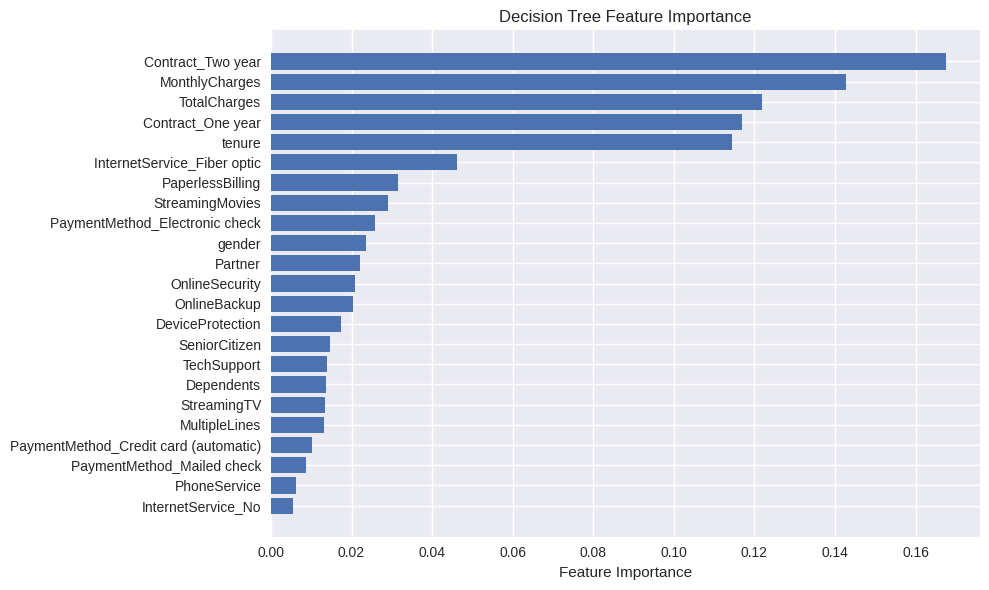

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained Decision Tree
importances = dt_model.feature_importances_
feature_names = X_train.columns

# Sort values for a cleaner graph
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

# Training & testing predicted probabilities
train_proba = best_dt.predict_proba(X_train)[:, 1]
test_proba = best_dt.predict_proba(X_test)[:, 1]

# ROC–AUC scores
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)

print("Training ROC-AUC:", train_auc)
print("Testing ROC-AUC:", test_auc)

Training ROC-AUC: 0.8961864506072832
Testing ROC-AUC: 0.7923661164070372


In [ ]:
train_pred = best_dt.predict(X_train_resampled)
train_acc = accuracy_score(y_train_resampled, train_pred)
print("Training Accuracy:", train_acc)


Training Accuracy: 0.8444068615607635


In [ ]:
test_pred = best_dt.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print("Testing Accuracy:", test_acc)


Testing Accuracy: 0.7416607523066004


# **Neural Network**

In [ ]:
import shutil
shutil.rmtree('nn_tuning',ignore_errors=True)

In [63]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Build NN model
model = tf.kerasSequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')   # binary classification
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

In [64]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42,stratify=y_train_resampled)

In [65]:
early_stop_base = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_base = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop_base],
    batch_size=32,
    verbose=1
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6939 - loss: 0.6360 - val_accuracy: 0.7579 - val_loss: 0.4932
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7472 - loss: 0.5163 - val_accuracy: 0.7645 - val_loss: 0.4767
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7637 - loss: 0.4904 - val_accuracy: 0.7705 - val_loss: 0.4678
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7671 - loss: 0.4866 - val_accuracy: 0.7784 - val_loss: 0.4638
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7712 - loss: 0.4710 - val_accuracy: 0.7856 - val_loss: 0.4587
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7813 - loss: 0.4718 - val_accuracy: 0.7760 - val_loss: 0.4612
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7759 - loss: 0.4717 - val_accuracy: 0.7832 - val_loss: 0.4552
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7786 - loss: 0.4622 - val_accu

In [67]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report :\n",classification_report(y_test,y_pred))

Accuracy : 0.7608232789212207
Precision: 0.5369261477045908
Recall   : 0.7192513368983957
F1 Score : 0.6148571428571429

Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def build_model(hp):
    model = Sequential()

    n_layers = hp.Int('num_layers', 1, 3)  # Number of hidden layers

    for i in range(n_layers):
        # Units per layer
        units = hp.Int(f'units_{i+1}', min_value=32, max_value=256, step=32)

        # Activation function per layer
        activation = hp.Choice(f'activation_{i+1}', values=['relu','selu'])

        if i == 0:
            # First layer with input shape
            model.add(Dense(units=units, activation=activation, input_shape=(X_train_resampled.shape[1],)))
        else:
            model.add(Dense(units=units, activation=activation))

        # Batch Normalization
        model.add(BatchNormalization())

        # Dropout
        dropout_rate = hp.Float(f'dropout_{i+1}', 0.0, 0.4, step=0.1)
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Learning rate
    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name="auc")]
    )

    return model


In [72]:
tuner = kt.Hyperband(
    hypermodel=build_model,
    objective=kt.Objective('auc', direction='max'),
    max_epochs=50,             # maximum epochs per model
    factor=3,                  # reduction factor
    hyperband_iterations=2,    # number of times to run Hyperband
    directory='nn_tuning',
    project_name='telco_churn_nn',
    seed=42,
    overwrite=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    X_train_final,
    y_train_final,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=32,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, verbose=0)]
)

Trial 92 Complete [00h 00m 14s]
auc: 0.8430641889572144

Best auc So Far: 0.9553049206733704
Total elapsed time: 00h 26m 02s

Search: Running Trial #93

Value             |Best Value So Far |Hyperparameter
1                 |3                 |num_layers
192               |192               |units_1
relu              |relu              |activation_1
0.3               |0                 |dropout_1
0.0005            |0.0005            |learning_rate
256               |32                |units_2
relu              |selu              |activation_2
0.1               |0                 |dropout_2
256               |256               |units_3
selu              |relu              |activation_3
0.3               |0                 |dropout_3
2                 |50                |tuner/epochs
0                 |17                |tuner/initial_epoch
3                 |1                 |tuner/bracket
0                 |1                 |tuner/round



In [60]:
best_hps = tuner.get_best_hyperparameters(1)[0]
best_hps.values
#print("Best units layer1:", best_hps.get('units_1'))
#print("Best units layer2:", best_hps.get('units_2'))
#print("Best dropout1:", best_hps.get('dropout_1'))
#print("Best dropout2:", best_hps.get('dropout_2'))
#print("Best learning rate:", best_hps.get('learning_rate'))

{'num_layers': 2,
 'units_1': 256,
 'activation_1': 'relu',
 'dropout_1': 0.0,
 'learning_rate': 0.001,
 'units_2': 128,
 'activation_2': 'selu',
 'dropout_2': 0.0,
 'units_3': 32,
 'activation_3': 'selu',
 'dropout_3': 0.4,
 'tuner/epochs': 50,
 'tuner/initial_epoch': 17,
 'tuner/bracket': 3,
 'tuner/round': 3,
 'tuner/trial_id': '0046'}

In [61]:
best_model = tuner.hypermodel.build(best_hps)

early_stop_tuned = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = best_model.fit(
    X_train_final,
    y_train_final,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    batch_size=32,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7439 - auc: 0.8207 - loss: 0.5359 - val_accuracy: 0.7566 - val_auc: 0.8469 - val_loss: 0.4929
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7886 - auc: 0.8637 - loss: 0.4583 - val_accuracy: 0.7911 - val_auc: 0.8796 - val_loss: 0.4347
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7825 - auc: 0.8714 - loss: 0.4457 - val_accuracy: 0.7977 - val_auc: 0.8720 - val_loss: 0.4501
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8036 - auc: 0.8849 - loss: 0.4224 - val_accuracy: 0.8043 - val_auc: 0.8786 - val_loss: 0.4419
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8149 - auc: 0.9009 - loss: 0.3965 - val_accuracy: 0.8031 - val_auc: 0.8860 - val_loss: 0.4416
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8335 - auc: 0.9096 - loss: 0.3748 - val_accuracy: 0.8110 - val_auc: 0.8821 - val_loss: 0.4339
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

In [62]:
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report :\n",classification_report(y_test,y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.7480482611781405
Precision: 0.5213483146067416
Recall   : 0.6203208556149733
F1 Score : 0.5665445665445665

Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.79      0.82      1035
           1       0.52      0.62      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.69      1409
weighted avg       0.76      0.75      0.75      1409



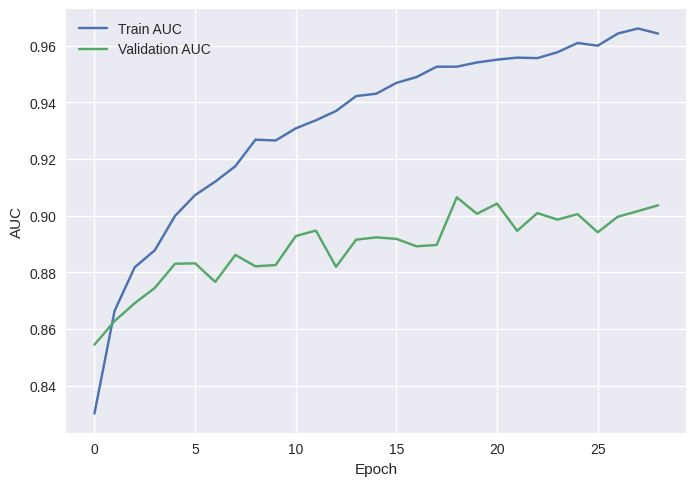

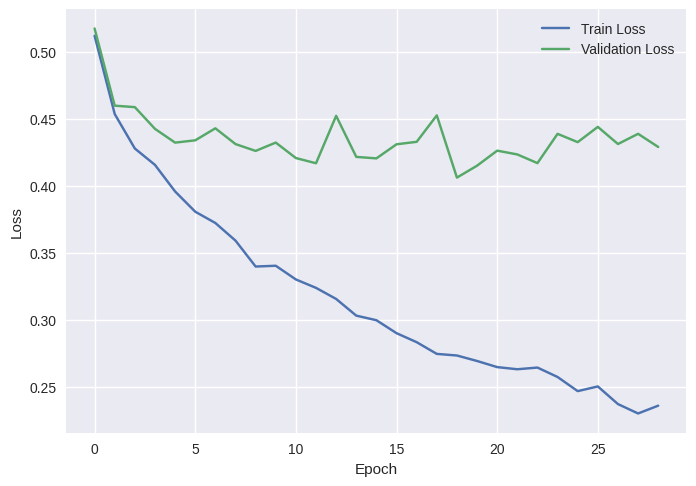

In [40]:
# AUC
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Confusion Matrix:
[[815 220]
 [127 247]]


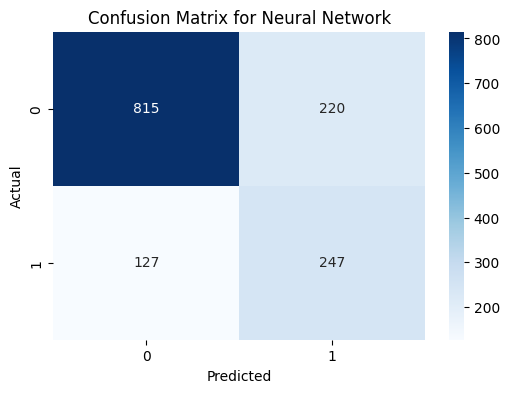

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict (returns probabilities)
#y_pred = best_model.predict(X_test)

# 2. Convert probabilities → class labels (0 or 1)
#y_pred_labels = (y_pred > 0.5).astype(int)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# 4. Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Neural Network")
plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


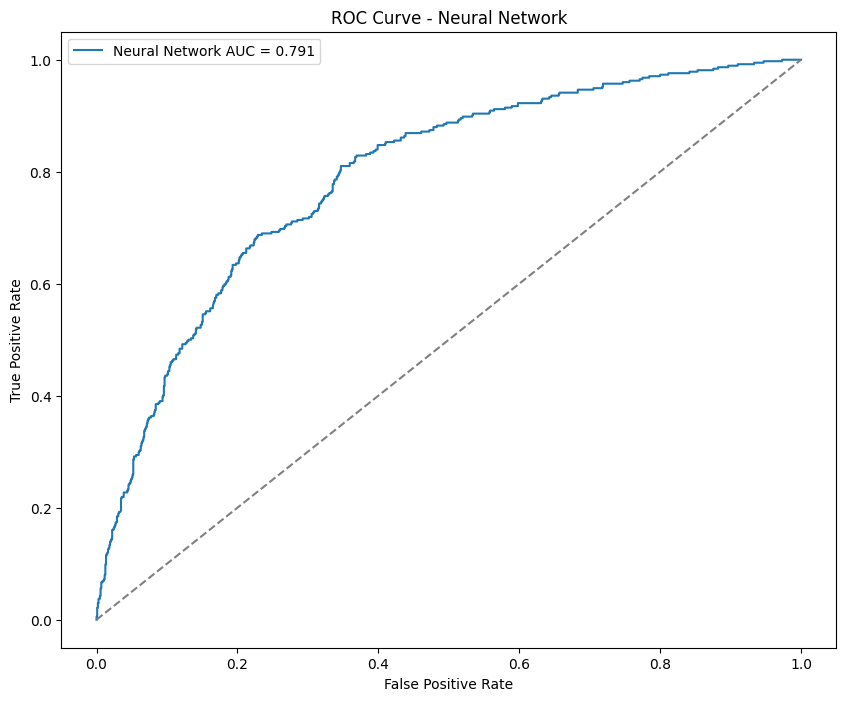

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_nn = best_model.predict(X_test).ravel()  # reshape output
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(10,8))
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network AUC = {auc_nn:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Neural Network')
plt.legend()
plt.show()

In [ ]:
train_pred = (best_model.predict(X_train_resampled) > 0.5).astype("int32")
train_acc = accuracy_score(y_train_resampled, train_pred)
print("Training Accuracy:", train_acc)

259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training Accuracy: 0.9124184585648707


In [ ]:
test_pred = (best_model.predict(X_test) > 0.5).astype("int32")
test_acc = accuracy_score(y_test, test_pred)
print("Testing Accuracy:", test_acc)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Testing Accuracy: 0.7537260468417317


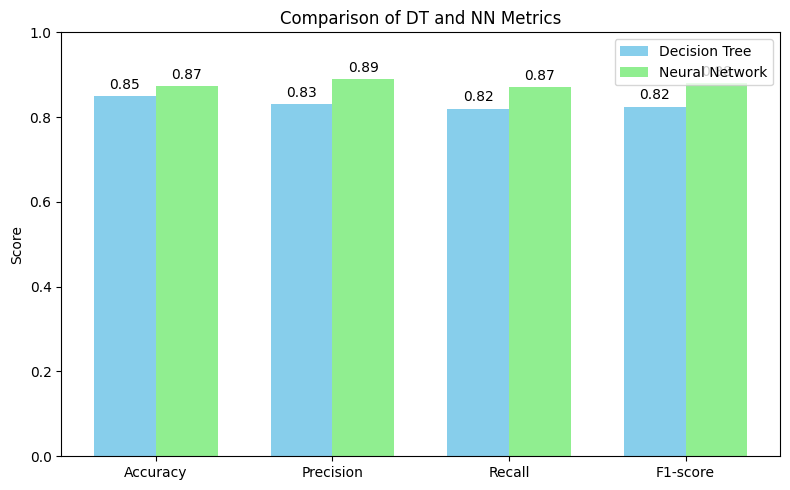

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example metrics for Decision Tree and Neural Network
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
dt_scores = [0.85, 0.83, 0.82, 0.825]  # replace with your DT results
nn_scores = [0.873, 0.89, 0.87, 0.88]  # replace with your NN results

x = np.arange(len(metrics))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, dt_scores, width, label='Decision Tree', color='skyblue')
rects2 = ax.bar(x + width/2, nn_scores, width, label='Neural Network', color='lightgreen')

# Add some text for labels, title and axes ticks
ax.set_ylabel('Score')
ax.set_title('Comparison of DT and NN Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Optional: annotate bars with their value
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


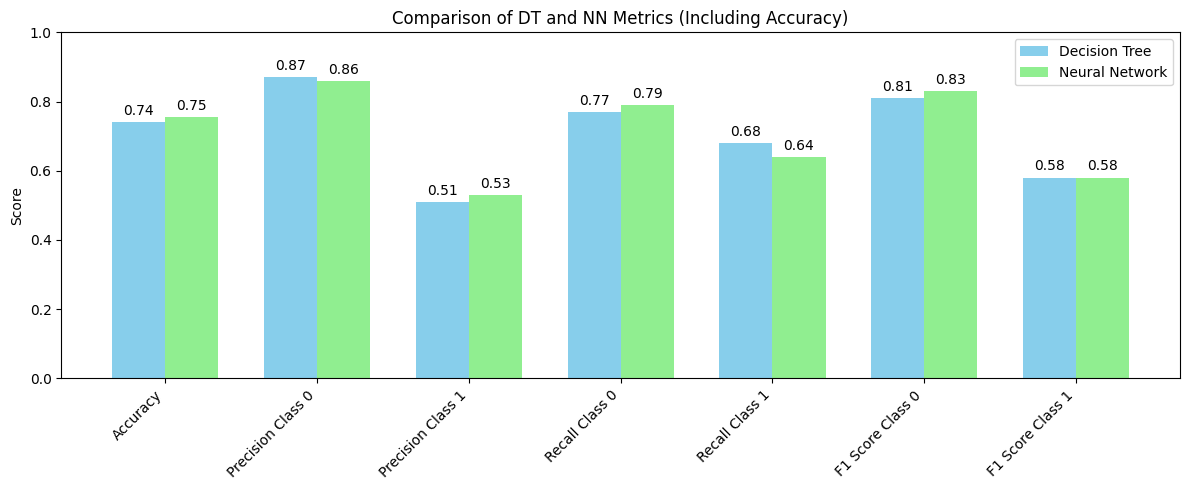

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels for the bars
metrics = ['Accuracy',
           'Precision Class 0', 'Precision Class 1',
           'Recall Class 0', 'Recall Class 1',
           'F1 Score Class 0', 'F1 Score Class 1']

# Decision Tree scores
dt_scores = [0.7417, 0.87, 0.51, 0.77, 0.68, 0.81, 0.58]

# Neural Network scores
nn_scores = [0.7544, 0.86, 0.53, 0.79, 0.64, 0.83, 0.58]

x = np.arange(len(metrics))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(12,5))

# Plot bars
rects1 = ax.bar(x - width/2, dt_scores, width, label='Decision Tree', color='skyblue')
rects2 = ax.bar(x + width/2, nn_scores, width, label='Neural Network', color='lightgreen')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Comparison of DT and NN Metrics (Including Accuracy)')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.legend()

# Annotate bars with values
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()
